# Machine Learning models

In this notebook we focus on training machine learning models to separate groups with CD vs nonIBD and UC vs nonIBD based only on the microbiome data.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kruskal
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (roc_auc_score, accuracy_score, f1_score,
                             precision_score, recall_score,
                             RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

# Load data
meta = pd.read_csv("../data/processed/metadata_final.tsv", sep="\t", index_col="Sample")
genera_clr = pd.read_csv("../data/processed/genera_clr.tsv", sep="\t", index_col=0)
meta = meta.loc[genera_clr.index]

print("Metadata shape:", meta.shape)
print("Genera CLR shape:", genera_clr.shape)
print("\nDiagnosis counts:")
print(meta["Study.Group"].value_counts())

Metadata shape: (105, 23)
Genera CLR shape: (105, 2761)

Diagnosis counts:
Study.Group
CD        49
UC        30
nonIBD    26
Name: count, dtype: int64


## Prepare two binary datasets

For the following of the analysis we create two completely separate datasets. Each has the same genera columns but different rows (subjects). The labels are binary: 1 for the IBD group and 0 for the nonIBD. We note again that the two classifiaction problems are independent.

In [3]:
def make_binary_dataset(meta, genera, group_a, group_b):
    """
    Filters metadata and genera to only include two groups.
    Returns X (features) and y (binary labels).
    """
    mask = meta["Study.Group"].isin([group_a, group_b])
    meta_sub = meta[mask]
    X = genera.loc[meta_sub.index]
    y = (meta_sub["Study.Group"] == group_a).astype(int)
    # 1 = group_a, 0 = group_b
    print(f"\n{group_a} vs {group_b}")
    print(f"  {group_a}: {(y==1).sum()} samples")
    print(f"  {group_b}: {(y==0).sum()} samples")
    print(f"  Total: {len(y)} samples")
    return X, y

X_uc, y_uc = make_binary_dataset(meta, genera_clr, "UC", "nonIBD")
X_cd, y_cd = make_binary_dataset(meta, genera_clr, "CD", "nonIBD")


UC vs nonIBD
  UC: 30 samples
  nonIBD: 26 samples
  Total: 56 samples

CD vs nonIBD
  CD: 49 samples
  nonIBD: 26 samples
  Total: 75 samples


## Feature Selection with Kruskal-Wallis filter

We keep the top 100 genera.

In [4]:
def kruskal_feature_selection(X, y, top_k):
    """
    Runs Kruskal-Wallis test for each genus between the two groups.
    Returns the names of the top_k most significant genera.
    """
    group0 = X[y == 0]
    group1 = X[y == 1]
    
    p_values = []
    for col in X.columns:
        stat, p = kruskal(group0[col].values, group1[col].values)
        p_values.append(p)
    
    p_series = pd.Series(p_values, index=X.columns)
    top_features = p_series.nsmallest(top_k).index.tolist()
    return top_features, p_series

# Run for both tasks, keep top 100 genera
print("=== UC vs nonIBD ===")
uc_features, uc_pvals = kruskal_feature_selection(X_uc, y_uc, top_k=100)
print(f"Top 100 genera selected by Kruskal-Wallis")
print(f"Best p-value: {uc_pvals.min():.4f}")

print("\n=== CD vs nonIBD ===")
cd_features, cd_pvals = kruskal_feature_selection(X_cd, y_cd, top_k=100)
print(f"Top 100 genera selected by Kruskal-Wallis")
print(f"Best p-value: {cd_pvals.min():.4f}")

=== UC vs nonIBD ===


Top 100 genera selected by Kruskal-Wallis
Best p-value: 0.0013

=== CD vs nonIBD ===
Top 100 genera selected by Kruskal-Wallis
Best p-value: 0.0007


## Feature Selection with PCA

We retain the 80% of the variance.

In [5]:
def pca_feature_selection(X, variance_threshold=0.80):
    """
    Applies PCA and keeps enough components to explain
    the target variance threshold.
    """
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    pca = PCA(n_components=min(X.shape[0]-1, X.shape[1]))
    pca.fit(X_scaled)
    
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    n_components = np.argmax(cumvar >= variance_threshold) + 1
    
    print(f"Components to explain {variance_threshold*100:.0f}% variance: {n_components}")
    print(f"Variance explained by first 10 PCs: {cumvar[9]*100:.1f}%")
    
    # Refit with correct number of components
    pca_final = PCA(n_components=n_components)
    X_pca = pca_final.fit_transform(X_scaled)
    
    return X_pca, pca_final, scaler, n_components

print("=== UC vs nonIBD ===")
X_uc_pca, pca_uc, scaler_uc, n_uc = pca_feature_selection(X_uc)

print("\n=== CD vs nonIBD ===")
X_cd_pca, pca_cd, scaler_cd, n_cd = pca_feature_selection(X_cd)

=== UC vs nonIBD ===
Components to explain 80% variance: 32
Variance explained by first 10 PCs: 47.6%

=== CD vs nonIBD ===
Components to explain 80% variance: 41
Variance explained by first 10 PCs: 44.4%


# Comments on the features

Both binary classification tasks seem to have modest biological signal. We do not expect a perfect classification, but a solid one that could improve adding more parameters to the process (like age, gender or BMI).

## Next Step: Cross Validation loop

We need to define all the models that we are going to use with their hyperparameters. Then we will pick the best of every combination. 

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": (
        LogisticRegression(max_iter=1000, random_state=42),
        {"C": [0.01, 0.1, 1, 10, 100]}
    ),
    "SVM": (
        SVC(probability=True, random_state=42),
        {"C": [0.1, 1, 10], "kernel": ["linear", "rbf"]}
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {"n_estimators": [100, 200], "max_depth": [3, 5, None]}
    ),
    "XGBoost": (
        XGBClassifier(random_state=42, eval_metric="logloss", verbosity=0),
        {"n_estimators": [100, 200], "max_depth": [3, 5],
         "learning_rate": [0.01, 0.1]}
    )
}

print("Models defined:")
for name, (model, params) in models.items():
    n_combinations = 1
    for v in params.values():
        n_combinations *= len(v)
    print(f"  {name}: {n_combinations} hyperparameter combinations")

Models defined:
  Logistic Regression: 5 hyperparameter combinations
  SVM: 6 hyperparameter combinations
  Random Forest: 6 hyperparameter combinations
  XGBoost: 8 hyperparameter combinations


In [7]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (roc_auc_score, accuracy_score, f1_score,
                             precision_score, recall_score)

def nested_cv(X, y, models, task_name, top_k=100, n_outer=5, n_inner=5):
    """
    Performs nested cross-validation with Kruskal-Wallis feature selection.
    
    Outer loop: evaluates model performance
    Inner loop: tunes hyperparameters
    Feature selection: happens inside outer loop to prevent data leakage
    """
    print(f"\n{'='*60}")
    print(f"Task: {task_name}")
    print(f"Samples: {len(y)}, Positives: {y.sum()}, Negatives: {(y==0).sum()}")
    print(f"{'='*60}")
    
    outer_cv = StratifiedKFold(n_splits=n_outer, shuffle=True, random_state=42)
    
    # Store results per model
    all_results = {name: {
        "auc": [], "accuracy": [], "f1": [],
        "precision": [], "recall": [],
        "y_true": [], "y_prob": []
    } for name in models}
    
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        print(f"\n--- Outer Fold {fold+1}/{n_outer} ---")
        
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # --- Feature selection on training data only ---
        # Kruskal-Wallis on X_train only (no leakage)
        p_values = []
        for col in X_train.columns:
            group0 = X_train[col][y_train == 0].values
            group1 = X_train[col][y_train == 1].values
            stat, p = kruskal(group0, group1)
            p_values.append(p)
        
        p_series = pd.Series(p_values, index=X_train.columns)
        top_features = p_series.nsmallest(top_k).index.tolist()
        
        X_train_sel = X_train[top_features]
        X_test_sel = X_test[top_features]
        
        # --- Inner loop: hyperparameter tuning ---
        inner_cv = StratifiedKFold(n_splits=n_inner, shuffle=True, random_state=42)
        
        for name, (model, param_grid) in models.items():
            grid_search = GridSearchCV(
                estimator=model,
                param_grid=param_grid,
                cv=inner_cv,
                scoring="roc_auc",
                n_jobs=-1
            )
            grid_search.fit(X_train_sel, y_train)
            best_model = grid_search.best_estimator_
            
            # --- Evaluate on outer test fold ---
            y_prob = best_model.predict_proba(X_test_sel)[:, 1]
            y_pred = best_model.predict(X_test_sel)
            
            auc = roc_auc_score(y_test, y_prob)
            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, zero_division=0)
            prec = precision_score(y_test, y_pred, zero_division=0)
            rec = recall_score(y_test, y_pred, zero_division=0)
            
            all_results[name]["auc"].append(auc)
            all_results[name]["accuracy"].append(acc)
            all_results[name]["f1"].append(f1)
            all_results[name]["precision"].append(prec)
            all_results[name]["recall"].append(rec)
            all_results[name]["y_true"].extend(y_test.tolist())
            all_results[name]["y_prob"].extend(y_prob.tolist())
            
            print(f"  {name:22s} AUC={auc:.3f}  "
                  f"Best params: {grid_search.best_params_}")
    
    return all_results


# Run for both tasks
results_uc_kw = nested_cv(X_uc, y_uc, models, task_name="UC vs nonIBD")
results_cd_kw = nested_cv(X_cd, y_cd, models, task_name="CD vs nonIBD")


Task: UC vs nonIBD
Samples: 56, Positives: 30, Negatives: 26

--- Outer Fold 1/5 ---
  Logistic Regression    AUC=0.444  Best params: {'C': 100}
  SVM                    AUC=0.444  Best params: {'C': 10, 'kernel': 'rbf'}
  Random Forest          AUC=0.556  Best params: {'max_depth': 5, 'n_estimators': 200}
  XGBoost                AUC=0.556  Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

--- Outer Fold 2/5 ---
  Logistic Regression    AUC=0.533  Best params: {'C': 100}
  SVM                    AUC=0.633  Best params: {'C': 1, 'kernel': 'rbf'}
  Random Forest          AUC=0.683  Best params: {'max_depth': 5, 'n_estimators': 100}
  XGBoost                AUC=0.533  Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

--- Outer Fold 3/5 ---
  Logistic Regression    AUC=0.700  Best params: {'C': 1}
  SVM                    AUC=0.567  Best params: {'C': 1, 'kernel': 'rbf'}
  Random Forest          AUC=0.267  Best params: {'max_depth': 3, 'n_e

In [8]:
def summarize_results(all_results, task_name):
    """
    Summarizes nested CV results into a clean DataFrame
    showing mean ± std across outer folds for each metric.
    """
    rows = []
    for name, metrics in all_results.items():
        rows.append({
            "Model": name,
            "AUC": f"{np.mean(metrics['auc']):.3f} ± {np.std(metrics['auc']):.3f}",
            "Accuracy": f"{np.mean(metrics['accuracy']):.3f} ± {np.std(metrics['accuracy']):.3f}",
            "F1": f"{np.mean(metrics['f1']):.3f} ± {np.std(metrics['f1']):.3f}",
            "Precision": f"{np.mean(metrics['precision']):.3f} ± {np.std(metrics['precision']):.3f}",
            "Recall": f"{np.mean(metrics['recall']):.3f} ± {np.std(metrics['recall']):.3f}",
            "AUC_mean": np.mean(metrics['auc'])  # for sorting
        })
    
    df = pd.DataFrame(rows).sort_values("AUC_mean", ascending=False)
    df = df.drop(columns="AUC_mean").reset_index(drop=True)
    
    print(f"\n{'='*60}")
    print(f"Results: {task_name}")
    print(f"{'='*60}")
    print(df.to_string(index=False))
    return df

df_uc_kw = summarize_results(results_uc_kw, "UC vs nonIBD (Kruskal-Wallis features)")
df_cd_kw = summarize_results(results_cd_kw, "CD vs nonIBD (Kruskal-Wallis features)")

# Save to results/tables
df_uc_kw.to_csv("../results/tables/ml_results_kw_uc.csv", index=False)
df_cd_kw.to_csv("../results/tables/ml_results_kw_cd.csv", index=False)
print("\nSaved results to results/tables/")


Results: UC vs nonIBD (Kruskal-Wallis features)
              Model           AUC      Accuracy            F1     Precision        Recall
                SVM 0.549 ± 0.095 0.574 ± 0.104 0.644 ± 0.103 0.591 ± 0.120 0.733 ± 0.170
Logistic Regression 0.542 ± 0.100 0.536 ± 0.060 0.604 ± 0.063 0.559 ± 0.061 0.667 ± 0.105
            XGBoost 0.491 ± 0.117 0.533 ± 0.150 0.577 ± 0.132 0.575 ± 0.145 0.600 ± 0.170
      Random Forest 0.434 ± 0.164 0.392 ± 0.134 0.432 ± 0.127 0.432 ± 0.123 0.433 ± 0.133

Results: CD vs nonIBD (Kruskal-Wallis features)
              Model           AUC      Accuracy            F1     Precision        Recall
Logistic Regression 0.665 ± 0.124 0.653 ± 0.078 0.743 ± 0.063 0.724 ± 0.092 0.773 ± 0.083
                SVM 0.637 ± 0.139 0.627 ± 0.116 0.740 ± 0.105 0.663 ± 0.071 0.853 ± 0.181
      Random Forest 0.626 ± 0.128 0.600 ± 0.073 0.718 ± 0.043 0.675 ± 0.080 0.776 ± 0.039
            XGBoost 0.581 ± 0.194 0.640 ± 0.080 0.740 ± 0.078 0.707 ± 0.083 0.820 ± 0.183

S

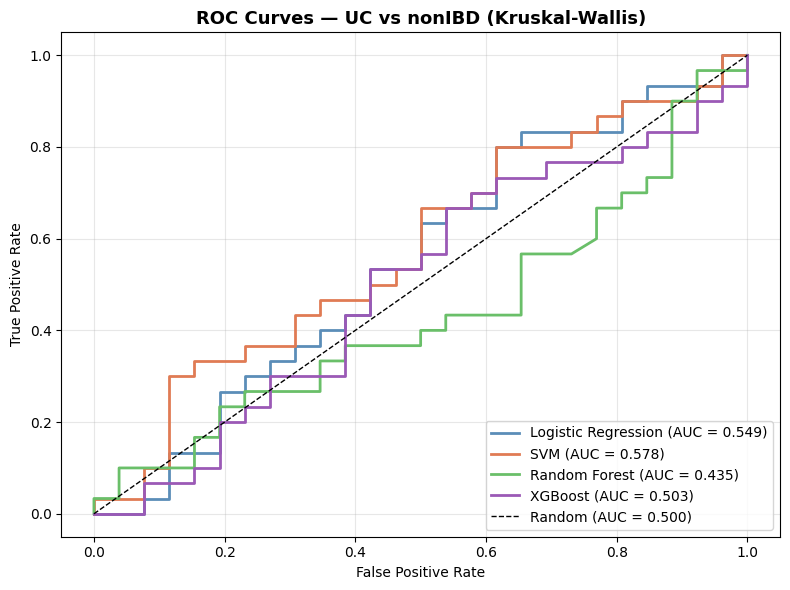

Saved: ../results/figures/13_roc_kw_uc.png


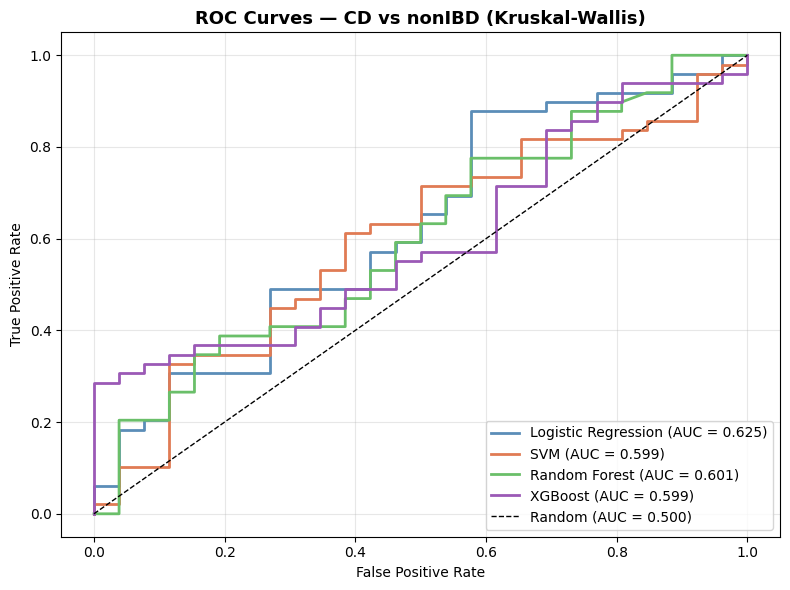

Saved: ../results/figures/14_roc_kw_cd.png


In [9]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curves(all_results, task_name, save_path):
    """
    Plots ROC curves for all models on the same figure.
    Uses aggregated predictions from all outer folds.
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    
    colors = ["#5b8db8", "#e07b54", "#6abf69", "#9b59b6"]
    
    for (name, metrics), color in zip(all_results.items(), colors):
        y_true = np.array(metrics["y_true"])
        y_prob = np.array(metrics["y_prob"])
        
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
        
        ax.plot(fpr, tpr, color=color, linewidth=2,
                label=f"{name} (AUC = {roc_auc:.3f})")
    
    # Random classifier baseline
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC = 0.500)")
    
    ax.set_title(f"ROC Curves — {task_name}", fontsize=13, fontweight="bold")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved: {save_path}")

plot_roc_curves(results_uc_kw, "UC vs nonIBD (Kruskal-Wallis)",
                "../results/figures/13_roc_kw_uc.png")

plot_roc_curves(results_cd_kw, "CD vs nonIBD (Kruskal-Wallis)",
                "../results/figures/14_roc_kw_cd.png")

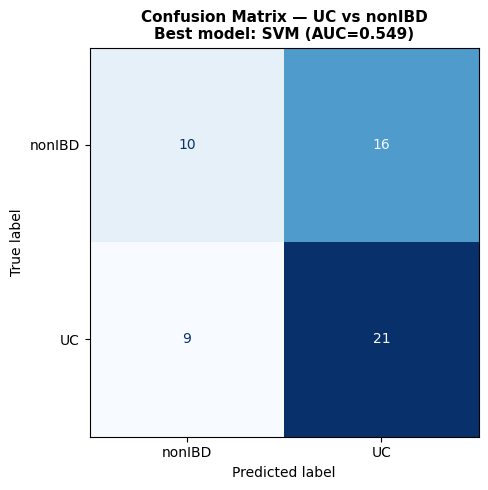

Best model: SVM
Saved: ../results/figures/15_confusion_kw_uc.png


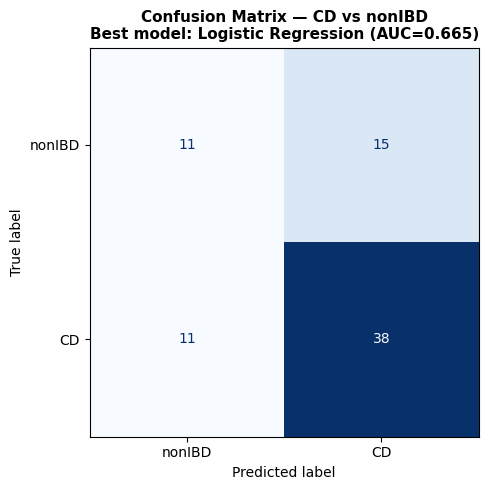

Best model: Logistic Regression
Saved: ../results/figures/16_confusion_kw_cd.png


In [10]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

def plot_confusion_matrix(all_results, task_name, class_names, save_path):
    """
    Plots confusion matrix for the best model (highest AUC).
    Uses aggregated predictions from all outer folds.
    """
    # Find best model by mean AUC
    best_name = max(all_results, key=lambda n: np.mean(all_results[n]["auc"]))
    best = all_results[best_name]
    
    y_true = np.array(best["y_true"])
    y_prob = np.array(best["y_prob"])
    y_pred = (y_prob >= 0.5).astype(int)
    
    cm = confusion_matrix(y_true, y_pred)
    
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    
    ax.set_title(f"Confusion Matrix — {task_name}\n"
                 f"Best model: {best_name} "
                 f"(AUC={np.mean(best['auc']):.3f})",
                 fontsize=11, fontweight="bold")
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Best model: {best_name}")
    print(f"Saved: {save_path}")

plot_confusion_matrix(results_uc_kw, "UC vs nonIBD",
                      class_names=["nonIBD", "UC"],
                      save_path="../results/figures/15_confusion_kw_uc.png")

plot_confusion_matrix(results_cd_kw, "CD vs nonIBD",
                      class_names=["nonIBD", "CD"],
                      save_path="../results/figures/16_confusion_kw_cd.png")